In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pybamm
model = pybamm.BaseModel()

In [44]:
R = pybamm.Parameter("Particle radius [m]")
D = pybamm.Parameter("Diffusion coefficient [m2.s-1]")
j = pybamm.Parameter("Interfacial current density [A.m-2]")
F = pybamm.Parameter("Faraday constant [C.mol-1]")
c0 = pybamm.Parameter("Initial concentration [mol.m-3]")

c = pybamm.Variable("Concentration [mol.m-3]", domain="negative particle")

In [45]:
# governing equations
N = -D * pybamm.grad(c)     # flux
dcdt = -pybamm.div(N)
model.rhs = {c: dcdt}

# boundary conditions
lbc = pybamm.Scalar(0)
rbc = -j / F / D
model.boundary_conditions = {c: {"left": (lbc, "Neumann"), "right": (rbc, "Neumann")}}

# initial conditions
model.initial_conditions = {c: c0}

In [46]:
model.variables = {
    "Concentration [mol.m-3]": c,
    "Surface concentration [mol.m-3]": pybamm.surf(c),
    "Flux [mol.m-2.s-1]": N,
}

# Using the model

In [47]:
# provide parameter values
param = pybamm.ParameterValues(
    {
        "Particle radius [m]": 10e-6,
        "Diffusion coefficient [m2.s-1]": 3.9e-14,
        "Interfacial current density [A.m-2]": 1.4,
        "Faraday constant [C.mol-1]": 96485,
        "Initial concentration [mol.m-3]": 2.5e4,
    }
)

In [48]:
# define and process geometry
r = pybamm.SpatialVariable(
    "r", domain=["negative particle"], coord_sys="spherical polar"
)
geometry = {"negative particle": {r: {"min": pybamm.Scalar(0), "max": R}}}

param.process_model(model)
param.process_geometry(geometry)

In [49]:
submesh_types = {"negative particle": pybamm.Uniform1DSubMesh}
var_pts = {r: 20}
mesh = pybamm.Mesh(geometry, submesh_types, var_pts)

spatial_methods = {"negative particle": pybamm.FiniteVolume()}
disc = pybamm.Discretisation(mesh, spatial_methods)
disc.process_model(model);

# Solving the model

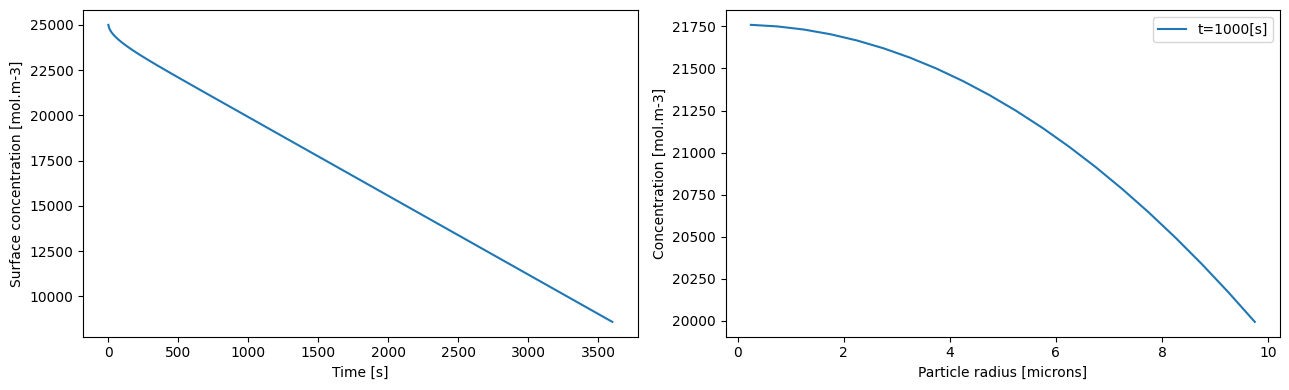

In [ ]:
# solve
solver = pybamm.ScipySolver()
t = np.linspace(0, 3600, 600)
solution = solver.solve(model, t)

# post-process, so that the solution can be called at any time t or space r
# (using interpolation)
c = solution["Concentration [mol.m-3]"]
c_surf = solution["Surface concentration [mol.m-3]"]

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(solution.t, c_surf(solution.t))
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Surface concentration [mol.m-3]")

r = mesh["negative particle"].nodes  # radial position
time = 1000  # time in seconds
ax2.plot(r * 1e6, c(t=time, r=r), label=f"t={time}[s]")
ax2.set_xlabel("Particle radius [microns]")
ax2.set_ylabel("Concentration [mol.m-3]")
ax2.legend()

plt.tight_layout()
plt.show()